# Desafio Looqbox - Resolução dos Exercícios de Python e SQL
Olá! Este notebook foi criado para mostrar as respostas da parte de Python do desafio da Looqbox. 
Aqui nós conectamos no banco de dados, criamos uma função para buscar vendas de forma bem flexível e fizemos dois gráficos bem legais para analisar os dados dos filmes do IMDB.

In [1]:
# Importando as bibliotecas que vamos usar no projeto
import mysql.connector
import pandas as pd
import numpy as np
from dotenv import load_dotenv
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Carregando as credenciais do banco que estão salvas no arquivo .env para segurança
load_dotenv(dotenv_path=r"C:\Users\Usuario\Downloads\desafio\cases\.venv\.env")

# Conectando no banco de dados da Looqbox
conn = mysql.connector.connect(
    host=os.getenv("DB_HOST"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    database=os.getenv("DB_NAME"),
    use_pure=True
)

print("Conexão estabelecida com sucesso!")

Conexão estabelecida com sucesso!


In [2]:
# Testando se a conexão está funcionando mesmo trazendo os 5 primeiros produtos da tabela
query = "SELECT * FROM data_product LIMIT 5"
df = pd.read_sql(query, conn)
df

C:\Users\Usuario\AppData\Local\Temp\ipykernel_24496\2392523468.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,PRODUCT_COD,PRODUCT_NAME,PRODUCT_VAL,DEP_NAME,DEP_COD,SECTION_NAME,SECTION_COD
0,10,Acido Tranexamico 250mg Generico EMS 12 Compri...,36.71,MEDICAMENTOS GENÉRICOS,10,CIRCULAÇÃO,40
1,11,Bissulfato de Clopidogrel 75mg Generico Teuto ...,66.51,MEDICAMENTOS GENÉRICOS,10,CIRCULAÇÃO,40
2,12,Cloridrato de Amiodarona 200mg Generico Biosin...,31.17,MEDICAMENTOS GENÉRICOS,10,CIRCULAÇÃO,40
3,13,Acido Tranexâmico 250mg Generico Legrand 12 Co...,36.71,MEDICAMENTOS GENÉRICOS,10,CIRCULAÇÃO,40
4,14,Cloridrato Oximetazolina Adulto 5mg/ml Genéric...,12.08,MEDICAMENTOS GENÉRICOS,10,GRIPES E RESFRIADOS,41


## 4 - Função Dinâmica para buscar dados de vendas (`retrieve_data`)

Criamos uma função chamada `retrieve_data` que serve para fazer buscas na tabela `data_product_sales` de um jeito muito prático. 

Ela foi pensada para ser bem flexível para que qualquer pessoa do time possa usar sem complicações. 

### O que você pode passar como filtro:
* `product_code`: Código do produto (pode ser um número só ou uma lista de códigos).
* `store_code`: Código da loja (pode ser uma loja só ou uma lista de várias lojas).
* `date_range`: Data ou período. Dá para passar uma data única ou um intervalo tipo `('2019-01-01', '2019-01-10')` para trazer tudo desse intervalo.

**Dica de Segurança:** Usamos o recurso de *query parametrizada* (passando os filtros separados da query principal) para evitar problemas de segurança, como ataques de SQL Injection!

In [3]:
def retrieve_data(conn, product_code=None, store_code=None, date_range=None):
    """
    Busca dados de vendas na tabela 'data_product_sales' aplicando filtros dinamicamente.
    """
    # Começamos com a consulta base trazendo todas as colunas de vendas
    query = "SELECT STORE_CODE, PRODUCT_CODE, DATE, SALES_VALUE, SALES_QTY FROM data_product_sales WHERE 1=1"
    params = []
    
    # Se o usuário passou códigos de produtos, filtramos aqui
    if product_code is not None:
        if isinstance(product_code, (list, tuple, set)):
            placeholders = ", ".join(["%s"] * len(product_code))
            query += f" AND PRODUCT_CODE IN ({placeholders})"
            params.extend(product_code)
        else:
            query += " AND PRODUCT_CODE = %s"
            params.append(product_code)
            
    # Se o usuário passou códigos de lojas, filtramos aqui
    if store_code is not None:
        if isinstance(store_code, (list, tuple, set)):
            placeholders = ", ".join(["%s"] * len(store_code))
            query += f" AND STORE_CODE IN ({placeholders})"
            params.extend(store_code)
        else:
            query += " AND STORE_CODE = %s"
            params.append(store_code)
            
    # Se o usuário passou datas, filtramos aqui
    if date_range is not None:
        # Se for um intervalo com data de início e de fim
        if isinstance(date_range, (list, tuple, set)) and len(date_range) == 2:
            query += " AND DATE BETWEEN %s AND %s"
            params.extend(date_range)
        # Se for uma data única
        else:
            query += " AND DATE = %s"
            params.append(date_range)
            
    # Executamos a query usando o pandas de forma segura
    df = pd.read_sql(query, conn, params=params)
    return df

# --- Vamos testar a função para ver se funciona bem! ---

print("Teste 1: Trazendo apenas vendas do produto com código 10")
df_t1 = retrieve_data(conn, product_code=10)
print(df_t1.head())

print("\nTeste 2: Trazendo vendas das lojas 1 e 2 no início de janeiro de 2019")
df_t2 = retrieve_data(conn, store_code=['1', '2'], date_range=('2019-01-01', '2019-01-10'))
print(df_t2.head())

Teste 1: Trazendo apenas vendas do produto com código 10


C:\Users\Usuario\AppData\Local\Temp\ipykernel_24496\1306151618.py:41: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn, params=params)


  STORE_CODE  PRODUCT_CODE        DATE  SALES_VALUE  SALES_QTY
0         10            10  2014-11-23      1014.75       99.0
1         10            10  2014-11-24      1076.25      105.0
2         10            10  2014-11-25      2388.25      233.0
3         10            10  2014-11-26      1599.00      156.0
4         10            10  2014-11-27      1547.75      151.0

Teste 2: Trazendo vendas das lojas 1 e 2 no início de janeiro de 2019
  STORE_CODE  PRODUCT_CODE        DATE  SALES_VALUE  SALES_QTY
0          1            18  2019-01-01        708.5       65.0
1          1            18  2019-01-02       1297.1      119.0
2          1            18  2019-01-03       1144.5      105.0
3          1            18  2019-01-04       1090.0      100.0
4          1            18  2019-01-05        893.8       82.0


C:\Users\Usuario\AppData\Local\Temp\ipykernel_24496\1306151618.py:41: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn, params=params)


## 5 - Gráficos com dados do IMDB (`IMDB_movies`)

Agora, vamos carregar a tabela `IMDB_movies` do banco de dados para criar alguns gráficos e entender melhor o que faz um filme faturar mais ou ser melhor avaliado.

In [4]:
# Buscando todos os filmes no banco
query_imdb = "SELECT * FROM IMDB_movies"
df_imdb = pd.read_sql(query_imdb, conn)

# Limpeza rápida: tiramos os filmes que não têm informação de faturamento (nulos) e garantimos os tipos corretos
df_clean = df_imdb.dropna(subset=['RevenueMillions']).copy()
df_clean['RevenueMillions'] = df_clean['RevenueMillions'].astype(float)
df_clean['Rating'] = df_clean['Rating'].astype(float)

print(f"Total de filmes lidos: {len(df_imdb)}, Filmes válidos para o gráfico: {len(df_clean)}")
df_clean.head()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_24496\3700329340.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_imdb = pd.read_sql(query_imdb, conn)


Total de filmes lidos: 1000, Filmes válidos para o gráfico: 872


,Id,Title,Genre,Director,Actors,Year,Runtime,Rating,Votes,RevenueMillions,Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.0,757074,333.0,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.0,65.0
2,3,Split,"Horror,Thriller",M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.0,157606,138.0,62.0
3,4,Sing,"Animation,Comedy,Family",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.0,60545,270.0,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.0,393727,325.0,40.0


### Gráfico 1: A nota do filme influencia no faturamento dele?

**Por que escolhemos este gráfico:**
Criamos um gráfico de dispersão (ou gráfico de pontos). Ele é ótimo para mostrar a relação entre duas informações numéricas ao mesmo tempo (a nota do filme e o quanto ele faturou). 
Adicionamos também uma linha vermelha que mostra a tendência dos pontos. Se a linha sobe, significa que, no geral, quanto maior a nota do filme, maior tende a ser o seu faturamento!

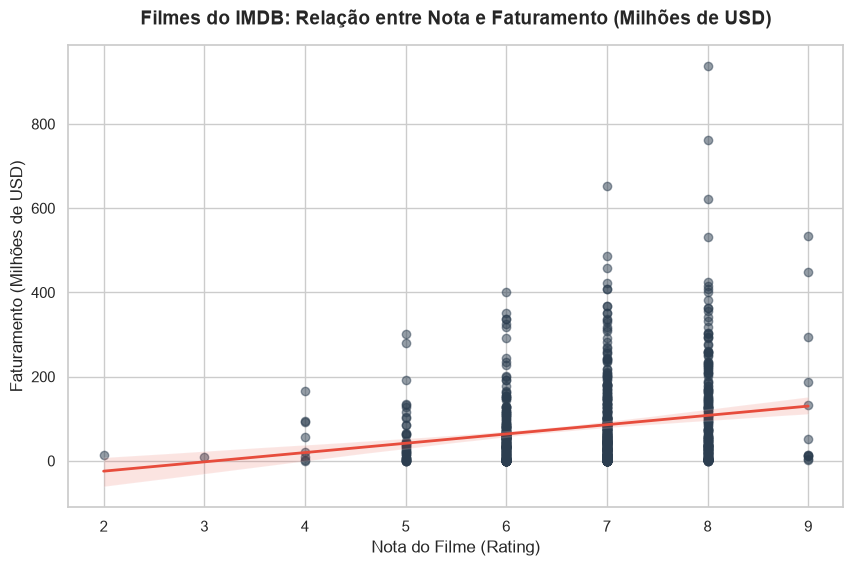

In [5]:
# Definindo o estilo visual dos gráficos
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Desenhando os pontos e a linha de tendência
sns.regplot(
    data=df_clean, 
    x='Rating', 
    y='RevenueMillions', 
    scatter_kws={'alpha': 0.5, 'color': '#2c3e50'}, # Pontos em azul escuro e um pouco transparentes
    line_kws={'color': '#e74c3c', 'linewidth': 2}   # Linha de tendência em vermelho
)

plt.title('Filmes do IMDB: Relação entre Nota e Faturamento (Milhões de USD)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nota do Filme (Rating)', fontsize=12)
plt.ylabel('Faturamento (Milhões de USD)', fontsize=12)

# Salvando a imagem do gráfico
plt.savefig('imdb_rating_vs_revenue.png', bbox_inches='tight', dpi=150)
plt.show()

### Gráfico 2: Qual é o faturamento médio por gênero de filme?

**Por que escolhemos este gráfico:**
Como a coluna `Genre` tem textos como `Action,Adventure,Sci-Fi` (vários gêneros juntos), nós usamos a função `split` e `explode` do Pandas para separar cada gênero em uma linha. 
Depois disso, calculamos a média de faturamento de cada gênero e fizemos um gráfico de barras horizontal com os 10 gêneros que mais faturam. O gráfico de barras é o melhor tipo para comparar categorias diferentes de forma bem direta e legível.

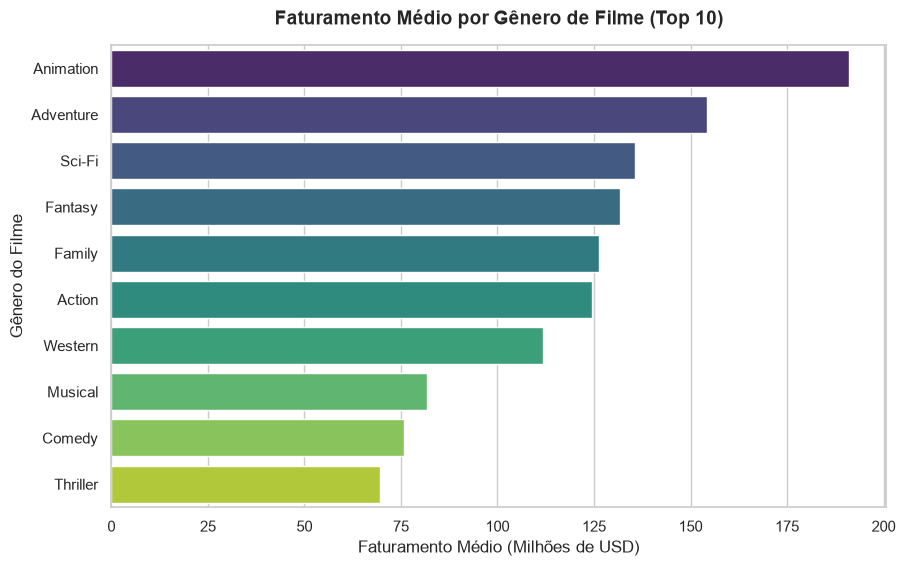

In [6]:
# Separando os gêneros de cada filme
df_genres = df_clean.assign(Genre=df_clean['Genre'].str.split(',')).explode('Genre')
df_genres['Genre'] = df_genres['Genre'].str.strip() # Remove espaços em branco nas pontas

# Calculando a média e pegando os Top 10
genre_summary = df_genres.groupby('Genre')['RevenueMillions'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=genre_summary.head(10),
    x='RevenueMillions',
    y='Genre',
    hue='Genre',
    legend=False,
    palette='viridis' # Paleta de cores moderna e bonita
)

plt.title('Faturamento Médio por Gênero de Filme (Top 10)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Faturamento Médio (Milhões de USD)', fontsize=12)
plt.ylabel('Gênero do Filme', fontsize=12)

# Salvando a imagem do gráfico
plt.savefig('imdb_genre_revenue.png', bbox_inches='tight', dpi=150)
plt.show()

### Encerrando a conexão com o banco
Sempre é bom fechar a conexão com o banco de dados depois que terminamos de usar para liberar recursos.

In [7]:
conn.close()
print("Conexão fechada com sucesso!")

Conexão fechada com sucesso!
